## Exemplo: Concentrações ao Nível do Solo a Sotavento de uma Fonte Pontual

Um poluente atmosférico não reativo é emitido de uma chaminé industrial a uma taxa de $m=10 \mathrm{~g} \mathrm{~s}^{-1}$. A altura efetiva da emissão é $H=50 \mathrm{~m}$. A velocidade média do vento é $U=3 \mathrm{~m} \mathrm{~s}^{-1}$. Preveja e plote as concentrações ao nível do solo a sotavento da fonte para duas classes de estabilidade: B (moderadamente instável) e E (ligeiramente estável).


### Solução

 Primeiro, os parâmetros de dispersão são obtidos das tabelas e equações vistas na última aula. Para as classes de estabilidade B e E, as expressões para $\sigma_y$ e $\sigma_z$ em função da distância a sotavento $x$ são as seguintes:

$$
\begin{array}{lll}
\text { Classe B: } & \sigma_y=154,7 x^{0,8932-0,006271 \ln (x)} & \sigma_z=109,8 x^{1,064+0,01163 \ln (x)} \\
\text { Classe E: } & \sigma_y=51,05 x^{0,9112-0,004845 \ln (x)} & \sigma_z=21,14 x^{0,6802-0,04522 \ln (x)}
\end{array}
$$


Em seguida, substituímos na equação \ref{eq:pluma_gaussiana_com_imagem} para obter uma expressão para a concentração em função da posição. Estamos interessados apenas nas concentrações ao nível do solo $(z = 0)$, portanto, a expressão se simplifica para a seguinte forma:

$$
C=\left(\frac{m}{\pi U \sigma_y \sigma_z}\right) \times \exp \left(-\frac{y^2}{2 \sigma_y^2}\right) \times \exp \left(-\frac{H^2}{2 \sigma_z^2}\right)
$$

Os parâmetros $m, U$ e $H$ são fornecidos no enunciado do problema, e as expressões para $\sigma_y$ e $\sigma_z$ em função de $x$ são apresentadas acima. A Figura a seguir mostra a concentração ao nível do solo ao longo da linha central da pluma $(y = 0)$ para as duas classes de estabilidade



In [1]:
# Importando as Bibliotecas
import numpy as np
import matplotlib.pyplot as plt

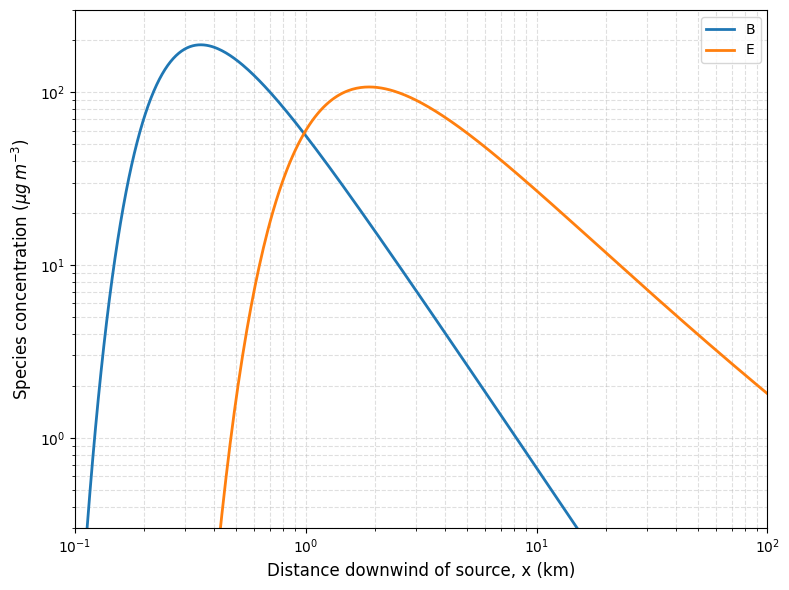

In [2]:
# ============================================================
# Parâmetros do problema
# ============================================================

m = 10.0       # g/s
U = 3.0        # m/s
H = 50.0       # m

# Distância downwind (km)
x_km = np.logspace(-1, 2, 500)

# ============================================================
# Coeficientes de dispersão (x em km)
# ============================================================

# Coeficientes de dispersão, com x em km
sigma_y_B = 154.7 * x_km**(0.8932 - 0.006271*np.log(x_km))
sigma_z_B = 109.8 * x_km**(1.064  + 0.01163*np.log(x_km))

sigma_y_E = 51.05 * x_km**(0.9112 - 0.004845*np.log(x_km))
sigma_z_E = 21.14 * x_km**(0.6802 - 0.04522*np.log(x_km))

# ============================================================
# Concentração ao nível do solo
#
# C = m/(pi*U*sigma_y*sigma_z)
#     * exp(-H²/(2*sigma_z²))
#
# ============================================================

C_B = (
    m / (np.pi * U * sigma_y_B * sigma_z_B)
    * np.exp(-(H**2)/(2*sigma_z_B**2))
)

C_E = (
    m / (np.pi * U * sigma_y_E * sigma_z_E)
    * np.exp(-(H**2)/(2*sigma_z_E**2))
)

# Converter de g/m³ para µg/m³
C_B *= 1e6
C_E *= 1e6

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.loglog(x_km, C_B, linewidth=2, label='B')
plt.loglog(x_km, C_E, linewidth=2, label='E')

plt.xlim(0.1, 100)
plt.ylim(0.3, 300)

plt.xlabel('Distance downwind of source, x (km)', fontsize=12)
plt.ylabel(r'Species concentration ($\mu g\,m^{-3}$)', fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

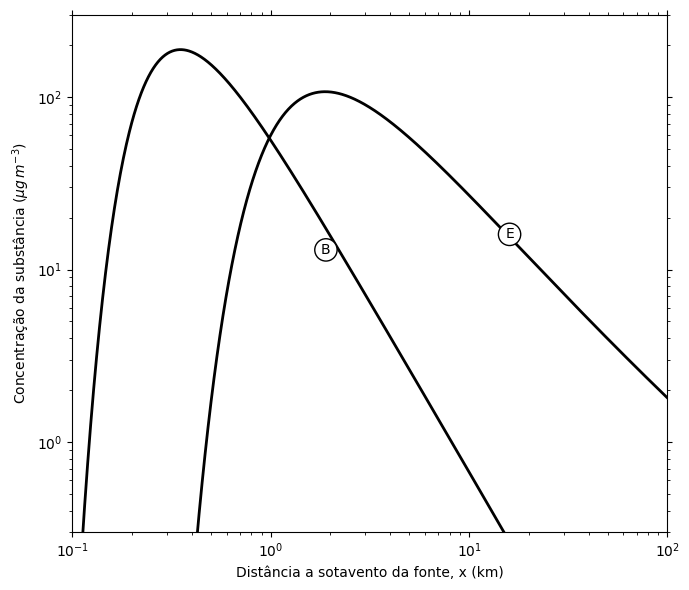

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dados do Exemplo 7.D.1
m = 10.0   # g/s
U = 3.0    # m/s
H = 50.0   # m

# Distância downwind em km
x = np.logspace(-1, 2, 1000)

# Coeficientes de dispersão, com x em km
sigma_y_B = 154.7 * x**(0.8932 - 0.006271*np.log(x))
sigma_z_B = 109.8 * x**(1.064  + 0.01163*np.log(x))

sigma_y_E = 51.05 * x**(0.9112 - 0.004845*np.log(x))
sigma_z_E = 21.14 * x**(0.6802 - 0.04522*np.log(x))

# Concentração ao nível do solo e na linha central da pluma
# y = 0, z = 0
C_B = (m / (np.pi * U * sigma_y_B * sigma_z_B)) * np.exp(-H**2 / (2*sigma_z_B**2))
C_E = (m / (np.pi * U * sigma_y_E * sigma_z_E)) * np.exp(-H**2 / (2*sigma_z_E**2))

# g/m³ para µg/m³
C_B *= 1e6
C_E *= 1e6

# Gráfico
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(x, C_B, color='black', linewidth=2)
ax.loglog(x, C_E, color='black', linewidth=2)

ax.set_xlim(0.1, 100)
ax.set_ylim(0.3, 300)

# ax.set_xlabel('Distance downwind of source, x (km)')
# ax.set_ylabel(r'Species concentration ($\mu g\,m^{-3}$)')
ax.set_xlabel('Distância a sotavento da fonte, x (km)')
ax.set_ylabel(r'Concentração da substância ($\mu g\,m^{-3}$)')

ax.text(1.9, 13, 'B',
        bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black'),
        ha='center', va='center')

ax.text(16, 16, 'E',
        bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black'),
        ha='center', va='center')

ax.grid(False)
ax.tick_params(which='both', direction='out', top=True, right=True)

plt.tight_layout()
plt.savefig('concentracao.png', dpi=300)
plt.show()

Isopletas são linhas que conectam pontos em um mapa que compartilham o mesmo valor de uma variável específica. No Brasil, elas são fundamentais na engenharia civil e arquitetura (segundo a norma ABNT NBR 6123) para determinar a velocidade básica do vento (em \(m/s\)) em cada região.



Já a próxima Figura mostra as curvas de nível de igual concentração de poluente ao nível do solo. Para a classe B, a concentração máxima é de aproximadamente $\sim 200 \mu \mathrm{~g} \mathrm{~m}^{-3}$ e ocorre a aproximadamente $\sim 350 \mathrm{~m}$ a sotavento da fonte. Devido à maior estabilidade atmosférica, a concentração máxima ao nível do solo para a classe E só ocorre quando a pluma se desloca mais longe da fonte, aproximadamente 2 km.

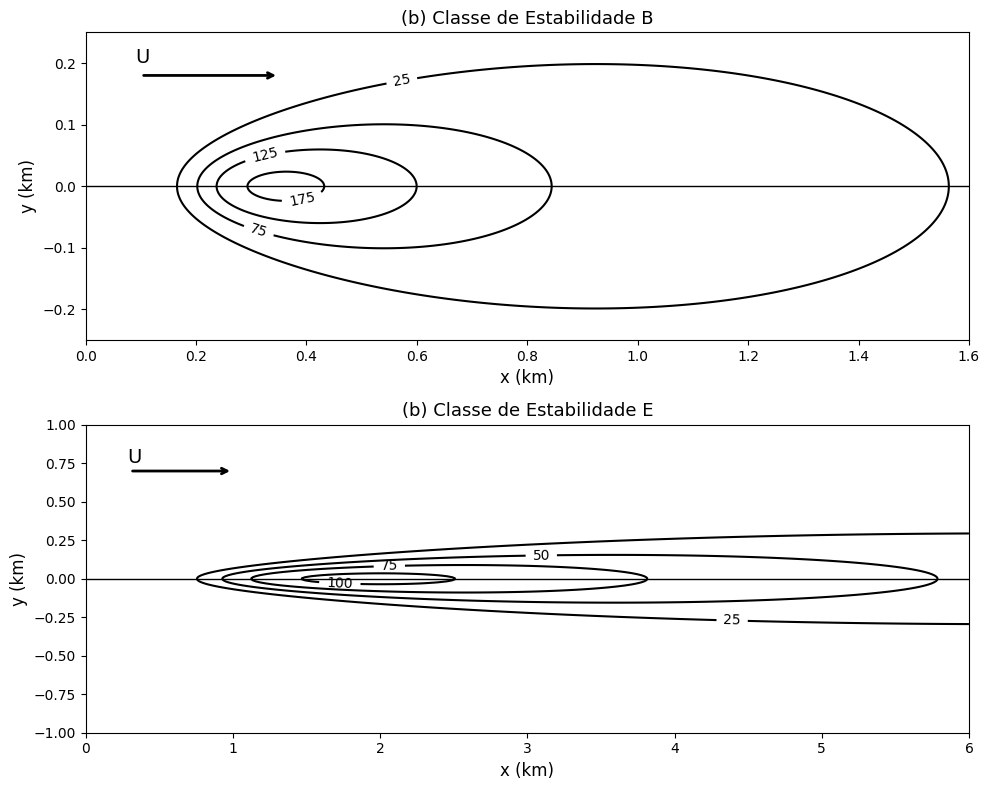

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Isopletas de concentração ao nível do solo
# Modelo Gaussiano de pluma
# ============================================================

# ------------------------------------------------------------
# Parâmetros da fonte
# ------------------------------------------------------------

m = 10.0      # taxa de emissão [g/s]
U = 3.0       # velocidade do vento [m/s]
H = 50.0      # altura efetiva da chaminé [m]

# ============================================================
# FUNÇÃO DE CONCENTRAÇÃO GAUSSIANA
# ============================================================

def gaussian_ground_concentration(x_km, y_km,
                                  sigma_y_func,
                                  sigma_z_func):
    """
    Concentração ao nível do solo (z=0)
    usando fonte imagem.

    Entrada:
        x_km, y_km : coordenadas em km

    Saída:
        C : concentração em µg/m³
    """

    # evitar divisão por zero
    x_km = np.maximum(x_km, 1e-6)

    # converter y para metros
    y = y_km * 1000.0

    # coeficientes de dispersão
    sigma_y = sigma_y_func(x_km)
    sigma_z = sigma_z_func(x_km)

    # equação gaussiana no solo
    C = (
        m / (np.pi * U * sigma_y * sigma_z)
        * np.exp(-(y**2)/(2*sigma_y**2))
        * np.exp(-(H**2)/(2*sigma_z**2))
    )

    # g/m³ -> µg/m³
    return C * 1e6


# ============================================================
# COEFICIENTES DE DISPERSÃO
# ============================================================

# ---------- Classe B ----------
def sigma_y_B(x):
    return 154.7 * x**(0.8932 - 0.006271*np.log(x))

def sigma_z_B(x):
    return 109.8 * x**(1.064  + 0.01163*np.log(x))


# ---------- Classe E ----------
def sigma_y_E(x):
    return 51.05 * x**(0.9112 - 0.004845*np.log(x))

def sigma_z_E(x):
    return 21.14 * x**(0.6802 - 0.04522*np.log(x))

# ============================================================
# MALHA - CLASSE B
# ============================================================

xB = np.linspace(0.01, 1.6, 400)
yB = np.linspace(-0.25, 0.25, 300)

XB, YB = np.meshgrid(xB, yB)

CB = gaussian_ground_concentration(
    XB, YB,
    sigma_y_B,
    sigma_z_B
)

# ============================================================
# MALHA - CLASSE E
# ============================================================

xE = np.linspace(0.01, 6.0, 500)
yE = np.linspace(-1.0, 1.0, 300)

XE, YE = np.meshgrid(xE, yE)

CE = gaussian_ground_concentration(
    XE, YE,
    sigma_y_E,
    sigma_z_E
)

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ============================================================
# (a) Classe B
# ============================================================

levels_B = [25, 75, 125, 175]

cs1 = axes[0].contour(
    XB, YB, CB,
    levels=levels_B,
    colors='black',
    linewidths=1.5
)

axes[0].clabel(cs1, inline=True, fontsize=10)

axes[0].set_xlim(0, 1.6)
axes[0].set_ylim(-0.25, 0.25)

axes[0].set_ylabel('y (km)', fontsize=12)
axes[0].set_xlabel('x (km)', fontsize=12)

#axes[0].set_title('(a) Stability class B', fontsize=13)
axes[0].set_title('(b) Classe de Estabilidade B', fontsize=13)

# vento
axes[0].annotate(
    '',
    xy=(0.35, 0.18),
    xytext=(0.10, 0.18),
    arrowprops=dict(arrowstyle='->', lw=2)
)

axes[0].text(0.09, 0.20, 'U', fontsize=14)

axes[0].axhline(0, color='black', linewidth=1)

# ============================================================
# (b) Classe E
# ============================================================

levels_E = [25, 50, 75, 100]

cs2 = axes[1].contour(
    XE, YE, CE,
    levels=levels_E,
    colors='black',
    linewidths=1.5
)

axes[1].clabel(cs2, inline=True, fontsize=10)

axes[1].set_xlim(0, 6)
axes[1].set_ylim(-1.0, 1.0)

axes[1].set_ylabel('y (km)', fontsize=12)
axes[1].set_xlabel('x (km)', fontsize=12)

#axes[1].set_title('(b) Stability class E', fontsize=13)
axes[1].set_title('(b) Classe de Estabilidade E', fontsize=13)

# vento
axes[1].annotate(
    '',
    xy=(1.0, 0.7),
    xytext=(0.3, 0.7),
    arrowprops=dict(arrowstyle='->', lw=2)
)

axes[1].text(0.28, 0.75, 'U', fontsize=14)

axes[1].axhline(0, color='black', linewidth=1)

# ============================================================

plt.tight_layout()
plt.savefig('isopletas.png', dpi=300)
plt.show()

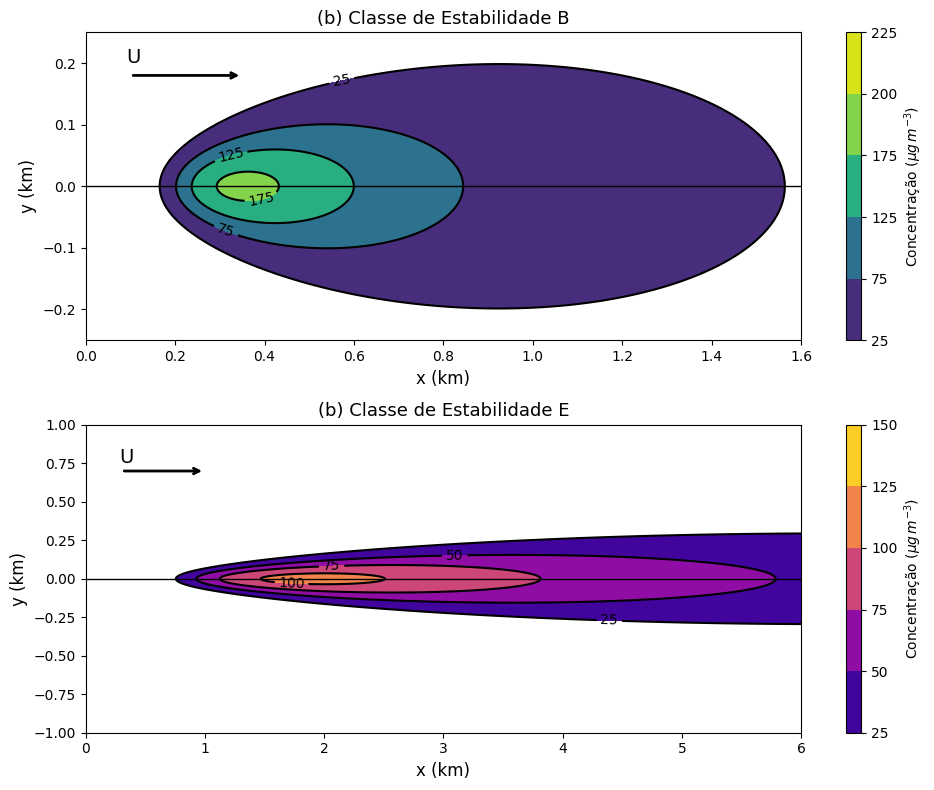

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Isopletas de concentração ao nível do solo
# Modelo Gaussiano de pluma
# ============================================================

# ------------------------------------------------------------
# Parâmetros da fonte
# ------------------------------------------------------------

m = 10.0      # taxa de emissão [g/s]
U = 3.0       # velocidade do vento [m/s]
H = 50.0      # altura efetiva da chaminé [m]

# ============================================================
# FUNÇÃO DE CONCENTRAÇÃO GAUSSIANA
# ============================================================

def gaussian_ground_concentration(x_km, y_km,
                                  sigma_y_func,
                                  sigma_z_func):
    """
    Concentração ao nível do solo (z=0)
    usando fonte imagem.

    Entrada:
        x_km, y_km : coordenadas em km

    Saída:
        C : concentração em µg/m³
    """

    # evitar divisão por zero
    x_km = np.maximum(x_km, 1e-6)

    # converter y para metros
    y = y_km * 1000.0

    # coeficientes de dispersão
    sigma_y = sigma_y_func(x_km)
    sigma_z = sigma_z_func(x_km)

    # equação gaussiana no solo
    C = (
        m / (np.pi * U * sigma_y * sigma_z)
        * np.exp(-(y**2)/(2*sigma_y**2))
        * np.exp(-(H**2)/(2*sigma_z**2))
    )

    # g/m³ -> µg/m³
    return C * 1e6


# ============================================================
# COEFICIENTES DE DISPERSÃO
# ============================================================

# ---------- Classe B ----------
def sigma_y_B(x):
    return 154.7 * x**(0.8932 - 0.006271*np.log(x))

def sigma_z_B(x):
    return 109.8 * x**(1.064  + 0.01163*np.log(x))


# ---------- Classe E ----------
def sigma_y_E(x):
    return 51.05 * x**(0.9112 - 0.004845*np.log(x))

def sigma_z_E(x):
    return 21.14 * x**(0.6802 - 0.04522*np.log(x))

# ============================================================
# MALHA - CLASSE B
# ============================================================

xB = np.linspace(0.01, 1.6, 400)
yB = np.linspace(-0.25, 0.25, 300)

XB, YB = np.meshgrid(xB, yB)

CB = gaussian_ground_concentration(
    XB, YB,
    sigma_y_B,
    sigma_z_B
)

# ============================================================
# MALHA - CLASSE E
# ============================================================

xE = np.linspace(0.01, 6.0, 500)
yE = np.linspace(-1.0, 1.0, 300)

XE, YE = np.meshgrid(xE, yE)

CE = gaussian_ground_concentration(
    XE, YE,
    sigma_y_E,
    sigma_z_E
)

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# ============================================================
# (a) Classe B
# ============================================================

levels_B = [25, 75, 125, 175, 200, 225]

# Filled contours
cf1 = axes[0].contourf(
    XB, YB, CB,
    levels=levels_B,
    cmap='viridis'
)
# Contour lines with labels
cs1 = axes[0].contour(
    XB, YB, CB,
    levels=levels_B,
    colors='black',
    linewidths=1.5
)

axes[0].clabel(cs1, inline=True, fontsize=10, fmt='%.0f')
fig.colorbar(cf1, ax=axes[0], label=r'Concentração ($μ g\,m^{-3}$)')

axes[0].set_xlim(0, 1.6)
axes[0].set_ylim(-0.25, 0.25)

axes[0].set_ylabel('y (km)', fontsize=12)
axes[0].set_xlabel('x (km)', fontsize=12)

axes[0].set_title('(b) Classe de Estabilidade B', fontsize=13)

# vento
axes[0].annotate(
    '',
    xy=(0.35, 0.18),
    xytext=(0.10, 0.18),
    arrowprops=dict(arrowstyle='->', lw=2)
)

axes[0].text(0.09, 0.20, 'U', fontsize=14)

axes[0].axhline(0, color='black', linewidth=1)

# ============================================================
# (b) Classe E
# ============================================================

levels_E = [25, 50, 75, 100, 125, 150]

# Filled contours
cf2 = axes[1].contourf(
    XE, YE, CE,
    levels=levels_E,
    cmap='plasma'
)
# Contour lines with labels
cs2 = axes[1].contour(
    XE, YE, CE,
    levels=levels_E,
    colors='black',
    linewidths=1.5
)

axes[1].clabel(cs2, inline=True, fontsize=10, fmt='%.0f')
fig.colorbar(cf2, ax=axes[1], label=r'Concentração ($μ g\,m^{-3}$)')

axes[1].set_xlim(0, 6)
axes[1].set_ylim(-1.0, 1.0)

axes[1].set_ylabel('y (km)', fontsize=12)
axes[1].set_xlabel('x (km)', fontsize=12)

axes[1].set_title('(b) Classe de Estabilidade E', fontsize=13)

# vento
axes[1].annotate(
    '',
    xy=(1.0, 0.7),
    xytext=(0.3, 0.7),
    arrowprops=dict(arrowstyle='->', lw=2)
)

axes[1].text(0.28, 0.75, 'U', fontsize=14)

axes[1].axhline(0, color='black', linewidth=1)

# ============================================================

plt.tight_layout()
plt.savefig('isopletas_color.png', dpi=300)
plt.show()